In [1]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [2]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.min = 0 # 最小弾数
        self.max = 0 # 最大弾数

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit or self.max-self.min>96000:

                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1

            if x <= 1/199.9 * 0.5:
                self.kaitensuu = 0
                self.balls += 280
                self.normal()
            elif x <= 1/199.9 * 0.505:
                self.kaitensuu = 0
                self.balls += 280
                self.rush()
            elif x <= 1/199.9 * 0.755:
                self.kaitensuu = 0
                self.balls += 1400
                self.rush()
            elif x <= 1/199.9:
                self.kaitensuu = 0
                self.balls += 1400
                self.normal()
    def rush(self):
        x = random.random()
        if x <= 0.7462284263:
            furiwake = random.random()
            if furiwake <= 0.97:
                self.balls += 2800
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
            else:
                self.balls += 5600
                if self.balls > self.max:
                    self.max = self.balls
                self.rush()
        else:
            self.normal()


In [ ]:
# results = []
# for i in tqdm(range(100)):
#     instance = spec(0, 0, 250, 20, 1000000)
#     a = instance.normal()
#     results.append(1000000*1000/a/4)
# print(np.mean(results))

100%|██████████| 100/100 [00:09<00:00, 10.12it/s]

16.719197274406994


In [11]:
result = []
for i in tqdm(range(100000)):
    instance = spec(0, 0, 0, 17, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


100%|██████████| 100000/100000 [00:28<00:00, 3492.94it/s]


平均収支:  566.3766647061555
標準偏差:  22375.713914648026
最大値:  157131.76470588465
最小値:  -29426.47058823442
5%点:  -24946.470588234555
95%点:  43933.52941176296


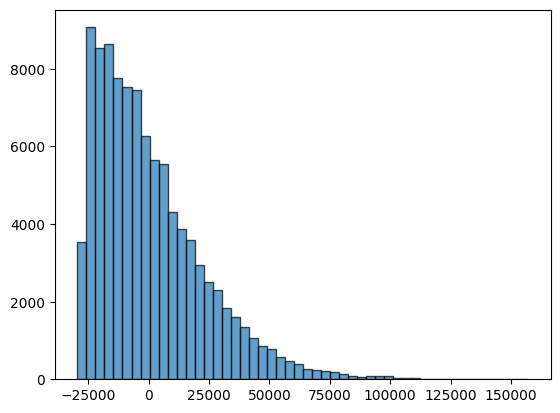

In [12]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()